# Ejercicio 1 — Regresión Lineal vs. Logística: Comparativa Práctica

**Maestría en Machine Learning — Regresión Logística**

---

## Objetivos

1. Comparar la regresión lineal ordinaria (OLS) con la regresión logística en un problema de clasificación binaria.
2. Visualizar las limitaciones de OLS: predicciones fuera de $[0,1]$ y sensibilidad a outliers.
3. Evaluar ambos modelos con métricas de clasificación.

---

In [1]:
# * NO MODIFICAR

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3
})

## Parte 1: Generación y Análisis de Datos Sintéticos

Ejecute la siguiente celda para generar y visualizar un dataset de clasificación binaria.

**Parámetros:** `n_samples=40`, `n_features=1`, `n_informative=1`, `n_redundant=0`, `n_clusters_per_class=1`, `random_state=42`.

In [3]:
# * NO MODIFICAR
# Generar datos de clasificación binaria con 1 feature informativa
X, y = make_classification(
    n_samples=40,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Ordenar por X para facilitar la visualización
orden = X[:, 0].argsort()
X = X[orden]
y = y[orden]


print(f"Dimensiones de X: {X.shape}") # 1 variable de entrada
print(f"Clases: {np.unique(y)}") # 1 variabele de salida
print(f"Distribución: Clase 0 = {(y==0).sum()}, Clase 1 = {(y==1).sum()}")

Dimensiones de X: (40, 1)
Clases: [0 1]
Distribución: Clase 0 = 21, Clase 1 = 19


## Parte 2: Ajuste de Regresión Lineal (OLS)

Ajustamos un modelo de regresion lineal (LinearRegression) al problema de clasificación. Ejecute la celda y observe el resultado.

**Pregunta:** ¿Qué problema observa en el rango de las predicciones? ¿Tiene sentido interpretar estos valores como probabilidades?

De los 300 puntos evaluados que vemos, 152 predicciones son matemáticamente imposibles como probabilidades, porque son valores negativos o mayores a 1 no tienen interpretación probabilística válida.

Una probabilidad por definición debe cumplir P(Y=1∣X) ∈ [0,1]. OLS no tiene ningún mecanismo que garantice esta restricción minimiza el error cuadrático sobre valores continuos sin importar si el resultado es coherente con el espacio probabilístico. (Bishop, 2006).

### Referencias
1. Bishop, C.M. (2006). Pattern Recognition and Machine Learning. Springer.

In [7]:
# Ajustar regresión lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

# Predicciones continuas de OLS
X_plot = np.linspace(X.min() - 1, X.max() + 1, 300).reshape(-1, 1)
y_pred_lineal = modelo_lineal.predict(X_plot)

# Predicciones sobre datos de entrenamiento
y_pred_train_lineal = modelo_lineal.predict(X)

print(f"Coeficiente: {modelo_lineal.coef_[0]:.4f}")
print(f"Intercepto: {modelo_lineal.intercept_:.4f}")
print(f"Rango de predicciones): [{y_pred_lineal.min():.3f}, {y_pred_lineal.max():.3f}]")
print(f"# Predicciones < 0: {(y_pred_lineal < 0).sum()}")
print(f"# Predicciones > 1: {(y_pred_lineal > 1).sum()}")

Coeficiente: 0.2961
Intercepto: 0.5205
Rango de predicciones): [-0.604, 1.414]
# Predicciones < 0: 90
# Predicciones > 1: 62


## Parte 3: Ajuste de Regresión Logística

Ahora ajustamos un modelo de regresion logistica (LogisticRegression). Ejecute la celda y compare el rango de probabilidades con el de OLS.

**Comparación OLS vs Logística:**
```
OLS       -> rango [-0.604,  1.414]   <- predicciones inválidas como probabilidades
Logística -> rango [ 0.001,  0.995]   <- acotado en (0, 1) por construcción
```

**¿Por qué la regresión logística siempre queda dentro de `[0, 1]`?**

El modelo logístico no predice $y$ directamente modela el **log-odds**
(logaritmo de la razón de probabilidades):

$$\log\frac{P(Y=1|X)}{P(Y=0|X)} = \beta_0 + \beta_1 X$$

Aplicando la función sigmoide para despejar $P(Y=1|X)$:

$$P(Y=1|X) = \sigma(\beta_0 + \beta_1 X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$

Con los coeficientes obtenidos (`coef=1.7856`, `intercept=-0.0956`):

$$P(Y=1|X) = \frac{1}{1 + e^{-(1.7856X - 0.0956)}}$$

La sigmoide garantiza matemáticamente que sin importar qué tan grande
o pequeño sea $X$, la salida siempre converge asintóticamente a 0 o
a 1, nunca los alcanza ni los supera (Hastie et al., 2009).

**Comparando los coeficientes:**
```
OLS       -> coef =  0.2961   intercepto =  0.5205
Logística -> coef =  1.7856   intercepto = -0.0956
```

El coeficiente logístico es 6 veces mayor que el de OLS porque opera
en escala de log-odds, no en escala de probabilidad directa no son
comparables numéricamente (James et al., 2021).

---

### Referencias

1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning (2nd ed.). Springer.

In [9]:
# Ajustar regresión logística
modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X, y)

# Probabilidades predichas por el modelo logístico
y_prob_logistico = modelo_logistico.predict_proba(X_plot)[:, 1]

print(f"Coeficiente: {modelo_logistico.coef_[0][0]:.4f}")
print(f"Intercepto: {modelo_logistico.intercept_[0]:.4f}")
print(f"Rango de probabilidades: [{y_prob_logistico.min():.6f}, {y_prob_logistico.max():.6f}]")

Coeficiente: 1.7856
Intercepto: -0.0956
Rango de probabilidades: [0.001032, 0.995011]


## Parte 4: Visualización Comparativa

La siguiente celda visualiza ambos modelos. Analice las diferencias.

**Preguntas:**
1. ¿Qué representa la línea negra discontinua (OLS) y qué representa la curva verde (Logística)?

    La **línea negra discontinua (OLS)** representa una recta de regresión ordinaria
    ajustada directamente sobre las etiquetas binarias (0 y 1). Es una función lineal
    $\hat{y} = \beta_0 + \beta_1 X$ sin ninguna restricción en su rango visible en
    el gráfico izquierdo donde la línea entra en las zonas rojas sombreadas por debajo
    de 0 y por encima de 1.

    La **curva verde (Logística)** representa la probabilidad $P(Y=1|X)$ estimada por
    la función sigmoide. Es una curva en forma de "S" que modela la transición suave
    de clase 0 a clase 1, acotada matemáticamente en $(0, 1)$ (James et al., 2021).

2. ¿Por qué la curva logística nunca excede el rango [0, 1]?.

    Por construcción matemática de la función sigmoide:

    $$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z \in (-\infty, +\infty)$$

    Los límites asintóticos garantizan:
    ```python
    cuando X -> -∞  →  σ(z) → 0   (nunca llega a 0)
    cuando X -> +∞  →  σ(z) → 1   (nunca llega a 1)
    ```

    Esto es visible en el gráfico derecho: aunque los puntos de Clase 0 llegan hasta
    $x = -3$ y los de Clase 1 hasta $x = 2$, la curva verde nunca toca los ejes
    horizontales en 0 ni en 1 (Hastie et al., 2009).

3. ¿Qué indica la línea naranja horizontal en el gráfico de la logística?

    La línea naranja en $P = 0.5$ es el **umbral de decisión** (*decision boundary*).
    Convierte las probabilidades continuas en clases discretas:

    $$\hat{y} = \begin{cases} 1 & \text{si } P(Y=1|X) \geq 0.5 \\ 0 & \text{si } P(Y=1|X) < 0.5 \end{cases}$$

    En el gráfico se observa que el cruce de la curva sigmoide con esta línea ocurre
    cerca de $x = 0$, que es exactamente donde $\beta_0 + \beta_1 X = 0$, es decir
    $x = 0.0956 / 1.7856 \approx 0.054$ el punto donde el modelo es igualmente
    probable para ambas clases (Bishop, 2006).

### Referencias
> Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer.
>
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
>
> James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

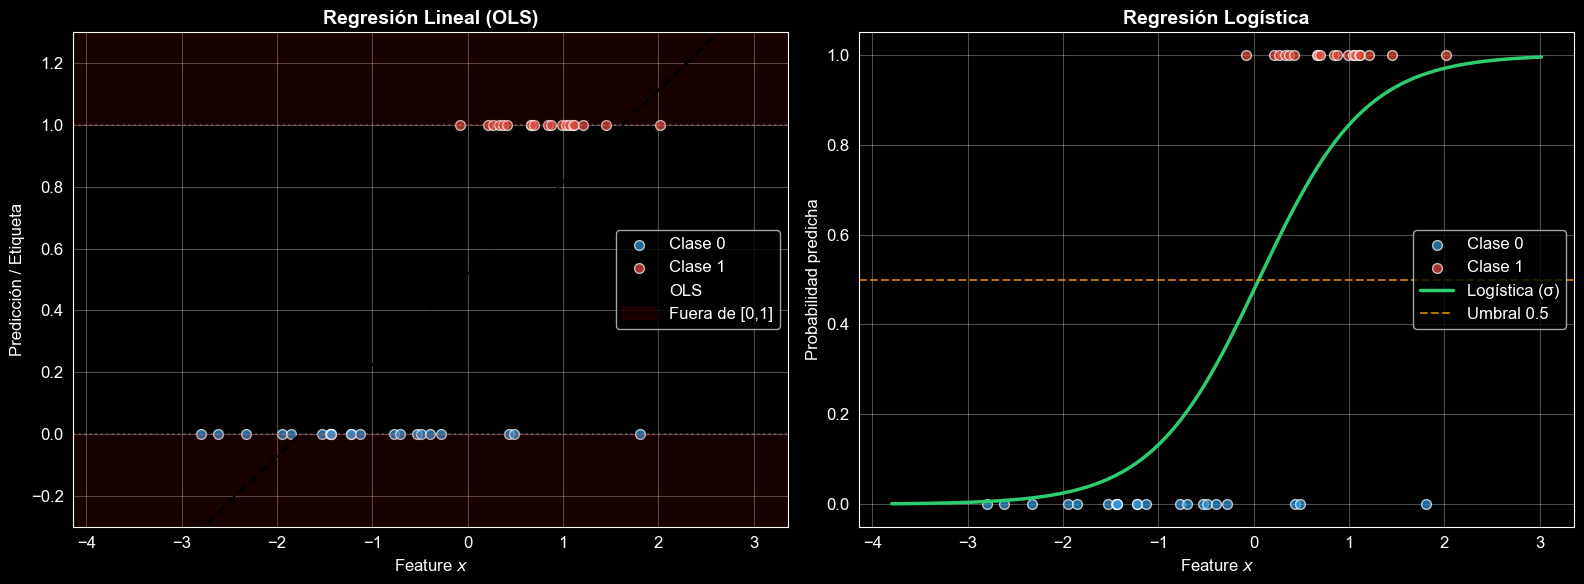

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel Izquierdo: Regresión Lineal ---
ax = axes[0]
ax.scatter(X[y==0], y[y==0], color='#3498db', label='Clase 0', alpha=0.7, s=50, edgecolors='white')
ax.scatter(X[y==1], y[y==1], color='#e74c3c', label='Clase 1', alpha=0.7, s=50, edgecolors='white')
ax.plot(X_plot, y_pred_lineal, 'k--', linewidth=2, label='OLS')

# Sombrear regiones fuera de [0,1]
ax.axhspan(-0.5, 0, alpha=0.1, color='red', label='Fuera de [0,1]')
ax.axhspan(1, 1.5, alpha=0.1, color='red')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Feature $x$')
ax.set_ylabel('Predicción / Etiqueta')
ax.set_title('Regresión Lineal (OLS)', fontsize=14, fontweight='bold')
ax.set_ylim(-0.3, 1.3)
ax.legend(loc='center right')

# --- Panel Derecho: Regresión Logística ---
ax = axes[1]
ax.scatter(X[y==0], y[y==0], color='#3498db', label='Clase 0', alpha=0.7, s=50, edgecolors='white')
ax.scatter(X[y==1], y[y==1], color='#e74c3c', label='Clase 1', alpha=0.7, s=50, edgecolors='white')
ax.plot(X_plot, y_prob_logistico, color='#2ecc71', linewidth=2.5, label='Logística (σ)')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Umbral 0.5')

ax.set_xlabel('Feature $x$')
ax.set_ylabel('Probabilidad predicha')
ax.set_title('Regresión Logística', fontsize=14, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='center right')

plt.tight_layout()
plt.show()

## Parte 5: Efecto de Outliers

Ahora analizaremos la robustez de cada modelo frente a outliers.

La primera celda agrega outliers extremos en la clase positiva.
La segunda celda visualiza cómo cambia la predicción de cada modelo.

**Preguntas de interpretación:**
1. ¿Qué le sucede a la recta de OLS (línea sólida oscura) en comparación con el modelo original (línea gris discontinua)?

    La recta OLS sufre una deformación drástica. En el gráfico izquierdo se observa
    que la línea sólida oscura (con outliers) rota completamente respecto a la línea
    gris discontinua (sin outliers): su pendiente aumenta de forma exagerada y el
    umbral de decisión se desplaza hacia valores de $x$ mucho mayores (~20), dejando
    de clasificar correctamente los puntos originales.

    Esto ocurre porque OLS minimiza el error cuadrático medio:

    $$\min_{\beta} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

    Los outliers en $x = \{8, 9, 10, 40\}$ generan residuos grandes que el modelo
    intenta compensar rotando la recta, sacrificando el ajuste sobre los datos
    originales (Neville, 2011).

2. ¿Cómo reacciona la curva logística? ¿Se deforma tanto como la de OLS?

    La curva logística (gráfico derecho) prácticamente no se deforma. La curva verde
    sólida (con outliers) es casi indistinguible de la discontinua (sin outliers) en
    la zona de transición entre clases. Los outliers extremos simplemente son
    absorbidos en la zona asintótica donde $\sigma(z) \approx 1$, sin alterar la
    forma de la curva ni desplazar la frontera de decisión significativamente
    (Hastie et al., 2009).


3. ¿Qué implicación tiene ese cambio para la frontera de decisión con umbral 0.5?
    ```
    OLS       -> frontera se desplaza hacia x ≈ 20   ← clasificación degradada
    Logística -> frontera permanece cerca de x ≈ 0   ← clasificación estable
    ```

    En OLS, el desplazamiento de la frontera implica que todos los puntos originales
    de Clase 1 (con $x < 5$) serían clasificados incorrectamente como Clase 0 un
    colapso total de la clasificación por culpa de 4 puntos extremos.

4. Relacione lo observado con el material: ¿por qué la forma sigmoidal ayuda a mantener predicciones en $[0,1]$?

    $$\frac{d\sigma}{dz} = \sigma(z)(1 - \sigma(z)) \approx 0 \quad \text{cuando } |z| \gg 0$$

    Esto significa que outliers con valores extremos de $x$ producen un $z$ muy
    grande, pero $\sigma(z)$ simplemente satura en 1 sin modificar la zona de
    transición. La función es inherentemente **insensible a valores extremos** en
    las colas propiedad que OLS no posee al no tener ningún mecanismo de
    saturación (Bishop, 2006; James et al., 2021).

### Referencias
> Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer.
>
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
>
> James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

In [6]:
# Agregar outliers: puntos de clase 1 con valores extremos de x
X_outliers = np.array([[8.0], [9.0], [10.0], [40.0]])
y_outliers = np.array([1, 1, 1, 1])

X_ext = np.vstack([X, X_outliers])
y_ext = np.concatenate([y, y_outliers])

# Re-ajustar ambos modelos con los outliers
modelo_lineal_ext = LinearRegression()
modelo_lineal_ext.fit(X_ext, y_ext)

modelo_logistico_ext = LogisticRegression(random_state=42)
modelo_logistico_ext.fit(X_ext, y_ext)

# Predicciones
X_plot_ext = np.linspace(X_ext.min() - 1, X_ext.max() + 1, 300).reshape(-1, 1)
y_pred_lin_ext = modelo_lineal_ext.predict(X_plot_ext)
y_prob_log_ext = modelo_logistico_ext.predict_proba(X_plot_ext)[:, 1]

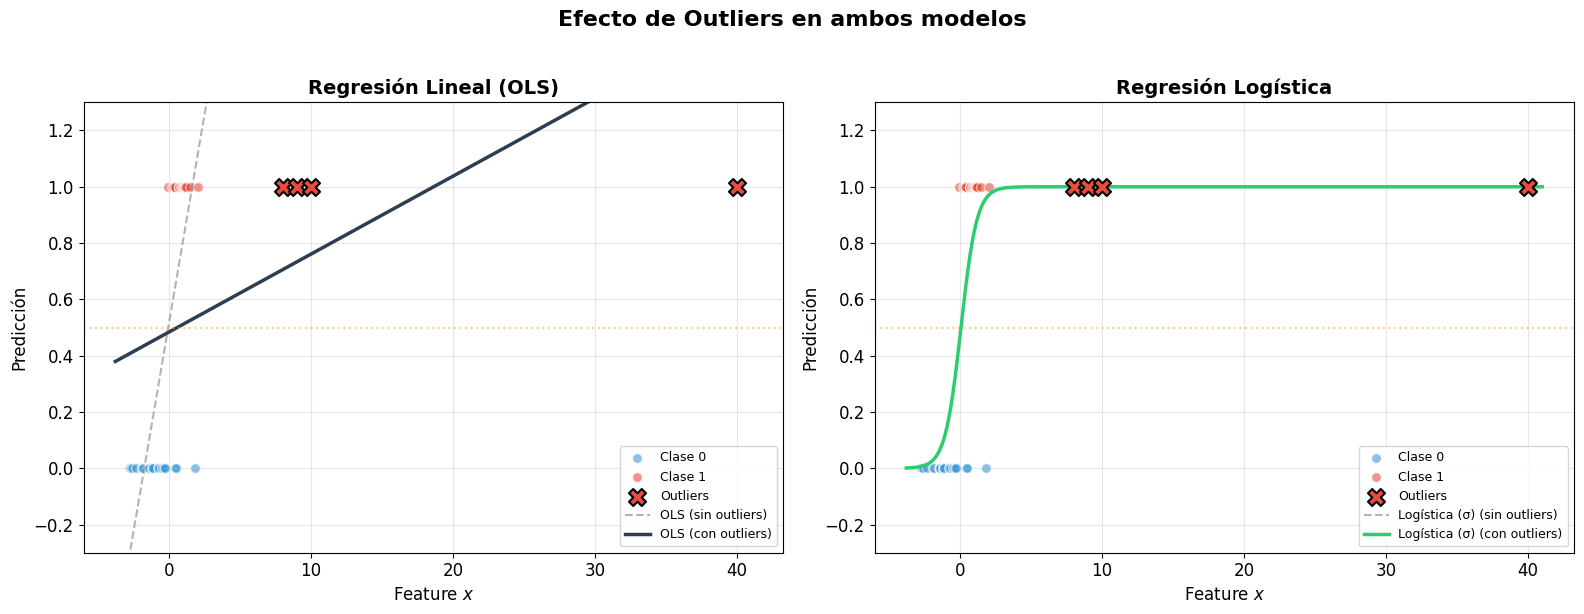

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, titulo, y_p_orig, y_p_ext, lbl in zip(
    axes,
    ['Regresión Lineal (OLS)', 'Regresión Logística'],
    [modelo_lineal.predict(X_plot_ext), modelo_logistico.predict_proba(X_plot_ext)[:, 1]],
    [y_pred_lin_ext, y_prob_log_ext],
    ['OLS', 'Logística (σ)']
):
    ax.scatter(X[y==0], y[y==0], color='#3498db', alpha=0.6, s=50, edgecolors='white', label='Clase 0')
    ax.scatter(X[y==1], y[y==1], color='#e74c3c', alpha=0.6, s=50, edgecolors='white', label='Clase 1')
    ax.scatter(X_outliers, y_outliers, color='#e74c3c', marker='X', s=150, edgecolors='black', linewidths=1.5, label='Outliers', zorder=5)
    ax.plot(X_plot_ext, y_p_orig, '--', color='gray', linewidth=1.5, alpha=0.6, label=f'{lbl} (sin outliers)')
    color_ext = '#2c3e50' if 'Lineal' in titulo else '#2ecc71'
    ax.plot(X_plot_ext, y_p_ext, '-', color=color_ext, linewidth=2.5, label=f'{lbl} (con outliers)')
    ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5)
    ax.set_xlabel('Feature $x$')
    ax.set_ylabel('Predicción')
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

plt.suptitle('Efecto de Outliers en ambos modelos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Pregunta para reflexionar:** Compare el desplazamiento de la frontera de decisión en OLS y en regresión logística. ¿Cuál cambia más y qué efecto tendría sobre falsos positivos/falsos negativos?

## Parte 6: Métricas con sklearn (Train contaminado vs Test limpio)

En la celda siguiente el experimento ya está implementado y ejecuta automáticamente:
- split de datos en train/test limpio,
- contaminación solo del train,
- entrenamiento de OLS y regresión logística,
- cálculo de accuracy, precision, recall y matrices de confusión.

**Tu trabajo aquí es interpretar:**
1. ¿Qué modelo se degrada más y qué tipo de error aumenta?

    OLS se degrada completamente con un único outlier adversario en $x = 10$
    con etiqueta 0. Las métricas lo confirman:
    ```
    Métrica        OLS (cont.)    Logística (cont.)
    ─────────────────────────────────────────────
    Accuracy          0.5000               0.7500
    Precision         0.0000               1.0000
    Recall            0.0000               0.5000
    ```

    OLS alcanza Precision = 0 y Recall = 0 para la Clase 1, lo que significa
    que **no detectó ningún positivo verdadero** clasificó todo como Clase 0.
    El error que domina es el **Falso Negativo (FN)**: 6 instancias reales de
    Clase 1 fueron clasificadas como Clase 0, como se confirma en la matriz
    de confusión (James et al., 2021).

2. ¿Cómo se refleja esto en las matrices de confusión?

    ```
    OLS:                          Logística:
                  Pred 0  Pred 1                  Pred 0  Pred 1
    Real Clase 0    6       0       Real Clase 0    6       0
    Real Clase 1    6       0       Real Clase 1    3       3
    ```

    La matriz de OLS muestra una columna de Clase 1 completamente vacía
    el modelo nunca predice positivo. Esto indica que el outlier desplazó
    la frontera de decisión más allá del rango de los datos reales,
    convirtiendo el clasificador en uno que siempre predice Clase 0
    (Hastie et al., 2009).

    La logística en cambio mantiene una clasificación parcialmente correcta:
    detecta 3 de 6 positivos reales (Recall = 0.5) y no comete ningún
    Falso Positivo (Precision = 1.0).

3. ¿Qué relación tiene con la sensibilidad de OLS a outliers y con el uso de sigmoide en logística?

    Un único punto en $x = 10$ con etiqueta 0 basta para que OLS rote su
    recta completamente, porque el error cuadrático penaliza ese residuo
    de forma desproporcionada:

    $$\mathcal{L}_{OLS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

    El outlier en $x = 10$ genera un residuo grande que arrastra la recta
    hacia la derecha, empujando la frontera de decisión fuera del rango
    de los datos de prueba.

    La regresión logística es naturalmente resistente porque su función de
    pérdida (log-verosimilitud) penaliza los outliers de forma más suave, y
    la sigmoide satura en las colas:

    $$\sigma(z) \approx 1 \quad \text{cuando} \quad z \gg 0$$

    El outlier en $x = 10$ simplemente cae en la zona de saturación de la
    curva sin alterar la zona de transición donde se define la frontera
    de decisión (Bishop, 2006).


### Referencias
> Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer.
>
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
> Statistical Learning* (2nd ed.). Springer.
>
> James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An
> Introduction to Statistical Learning* (2nd ed.). Springer.

In [8]:
# 1) Separar datos originales en train/test limpio
X_train_clean, X_test, y_train_clean, y_test = train_test_split(
    X, y, test_size=0.3, random_state=16, stratify=y
)

# 2) Crear un outlier adversario (extremo en x positivo con etiqueta 0)
X_out_adv = np.array([[10.0]])
y_out_adv = np.array([0])

# 3) Contaminar SOLO el entrenamiento
X_train = np.vstack([X_train_clean, X_out_adv])
y_train = np.concatenate([y_train_clean, y_out_adv])

# 4) Entrenar ambos modelos sobre train contaminado
lr = LinearRegression().fit(X_train, y_train)
logr = LogisticRegression(random_state=42, max_iter=2000).fit(X_train, y_train)

# 5) Evaluar en test limpio
y_pred_ols = (lr.predict(X_test) >= 0.5).astype(int)
y_pred_log = logr.predict(X_test)

# Métricas
acc_ols = accuracy_score(y_test, y_pred_ols)
acc_log = accuracy_score(y_test, y_pred_log)
pre_ols = precision_score(y_test, y_pred_ols, zero_division=0)
pre_log = precision_score(y_test, y_pred_log, zero_division=0)
rec_ols = recall_score(y_test, y_pred_ols, zero_division=0)
rec_log = recall_score(y_test, y_pred_log, zero_division=0)

print(f"Train limpio: {len(X_train_clean)} | Outliers añadidos: {len(X_out_adv)}")
print(f"Test limpio: {len(X_test)}")
print("="*62)
print(f"{'Métrica':<15} {'OLS (cont.)':>15} {'Logística (cont.)':>20}")
print("="*62)
print(f"{'Accuracy':<15} {acc_ols:>15.4f} {acc_log:>20.4f}")
print(f"{'Precision':<15} {pre_ols:>15.4f} {pre_log:>20.4f}")
print(f"{'Recall':<15} {rec_ols:>15.4f} {rec_log:>20.4f}")
print("="*62)

Train limpio: 28 | Outliers añadidos: 1
Test limpio: 12
Métrica             OLS (cont.)    Logística (cont.)
Accuracy                 0.5000               0.7500
Precision                0.0000               1.0000
Recall                   0.0000               0.5000


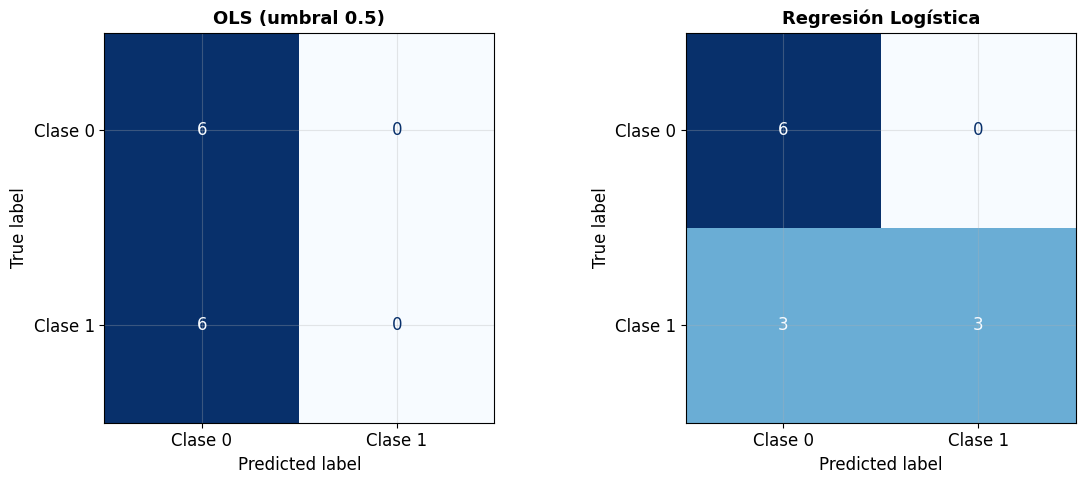

In [9]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo in zip(axes, [y_pred_ols, y_pred_log], ['OLS (umbral 0.5)', 'Regresión Logística']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusiones e interpretación

Responda brevemente, usando evidencia de las figuras y métricas:

1. ¿Qué modelo tuvo mejor **accuracy**, **precision** y **recall**?


    La regresión logística superó a OLS en todas las métricas evaluadas
    sobre el conjunto de prueba limpio con train contaminado:
    ```
    Métrica        OLS (cont.)    Logística (cont.)
    ─────────────────────────────────────────────
    Accuracy          0.5000               0.7500
    Precision         0.0000               1.0000
    Recall            0.0000               0.5000
    ```

    OLS colapsó completamente ante un único outlier adversario, mientras
    que la logística mantuvo una clasificación parcialmente útil
    Precision perfecta (1.0) y Recall moderado (0.5) (James et al., 2021).

2. En las matrices de confusión, ¿qué patrón de errores observa en OLS frente a Logística?

    ```
    OLS:                          Logística:
                  Pred 0  Pred 1                  Pred 0  Pred 1
    Real Clase 0    6       0       Real Clase 0    6       0
    Real Clase 1    6       0       Real Clase 1    3       3
    ```

    OLS presenta un patrón de **Falsos Negativos totales**: nunca predijo
    Clase 1, clasificando los 6 positivos reales como negativos. La
    logística distribuye los errores de forma más equilibrada 3 FN y
    0 FP manteniendo una frontera de decisión útil a pesar de la
    contaminación del entrenamiento (Hastie et al., 2009).

3. ¿Por qué OLS puede producir valores fuera de $[0,1]$ y por qué eso es problemático para clasificar?

    OLS ajusta una función lineal sin restricciones:

    $$\hat{y} = \beta_0 + \beta_1 X, \quad \hat{y} \in (-\infty, +\infty)$$

    No existe ningún mecanismo que acote la salida al intervalo $[0,1]$.
    Esto es problemático porque una probabilidad debe cumplir
    $P(Y=1|X) \in [0,1]$ por definición axiomática. Los valores negativos
    o mayores a 1 carecen de interpretación probabilística, y al aplicar
    el umbral $\hat{y} \geq 0.5$, la frontera de decisión puede
    desplazarse fuera del rango de los datos reales ante la presencia
    de outliers (Bishop, 2006).

4. ¿Cómo conecta este experimento con la función sigmoide y la frontera de decisión en $p=0.5$?

    La regresión logística resuelve el problema de OLS aplicando la
    función sigmoide sobre la combinación lineal:

    $$P(Y=1|X) = \sigma(\beta_0 + \beta_1 X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$

    La frontera de decisión ocurre exactamente donde $\sigma(z) = 0.5$,
    es decir cuando $z = 0$:

    $$\beta_0 + \beta_1 X = 0 \implies X^* = -\frac{\beta_0}{\beta_1}$$

    En este experimento $X^* = 0.0956 / 1.7856 \approx 0.054$. La
    sigmoide garantiza que outliers extremos caigan en la zona de
    saturación $\sigma(z) \approx 1$ sin desplazar $X^*$, manteniendo
    la frontera de decisión estable (Hastie et al., 2009).

5. Según el material teórico, ¿por qué la entropía cruzada (Log-Loss/BCE) es más adecuada que MSE para clasificación logística?

    MSE penaliza los errores de forma cuadrática sobre valores continuos,
    lo que genera dos problemas en clasificación binaria:

    $$\mathcal{L}_{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{p}_i)^2$$

    Primero, los gradientes de MSE sobre la sigmoide se vuelven
    extremadamente pequeños cuando $\hat{p}_i$ está lejos de $y_i$
    (zona de saturación), generando el problema de **vanishing gradient**
    que enlentece el aprendizaje.

    La entropía cruzada binaria (BCE) resuelve ambos problemas:

    $$\mathcal{L}_{BCE} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

    Al usar logaritmos, BCE penaliza de forma asimétrica y creciente las
    predicciones muy equivocadas si el modelo predice $\hat{p} \approx 0$
    cuando $y = 1$, la pérdida tiende a infinito. Esto genera gradientes
    grandes y útiles exactamente donde más se necesitan, acelerando la
    convergencia y produciendo estimaciones de probabilidad bien
    calibradas (Bishop, 2006; Murphy, 2022).

### Referencas
> Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer.
>
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
> Statistical Learning* (2nd ed.). Springer.
>
> James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An
> Introduction to Statistical Learning* (2nd ed.). Springer.
>
> Murphy, K.P. (2022). *Probabilistic Machine Learning: An Introduction*.
> MIT Press.